# [7.1] Logit Lens, Tuned Lens, and Patchscopes - Solutions

By the end of this notebook, you will have shown that residual-stream activations in a trained transformer become increasingly decodable as the model computes the next token, and that Patchscope-style activation insertion carries answer information beyond text-only prompt priors.

## Core Question

When a decoder says an activation means a token, what evidence makes that claim stronger than a prompt prior or a plausible story?

```yaml
gt_tier: GT-1 activation-to-language preflight
exercise_id: 7_1_logit_lens_tuned_lens_and_patchscopes
expected_runtime: 60-90 minutes for local exercises; several minutes for the pinned CPU Pythia signature result
requires_gpu: false
```

## Learning Objectives

- Implement logit lens, tuned lens, attention lens, and Patchscope-style activation insertion from tensors.
- Build toy oracles where every expected token and rank is known before touching a real model.
- Fit a ridge tuned lens on a train split and judge it only on held-out positions.
- Compare Patchscope answers against text-only prompts, counterfactual activations, and random activations.
- Produce a visible table/plot with real Pythia prompts, tokens, decoded answers, and controls.

<details>
<summary>Expected output</summary>

The local tests should each print an `All tests ... passed!` line. The signature result should show real six-layer Pythia token rows, a bar plot where tuned-lens held-out accuracy beats ordinary logit lens, and a Patchscope table where patched activations beat the same target prompt without the activation.

</details>

<details>
<summary>Help - how to read this notebook</summary>

Treat every decoded token as a hypothesis about what a specific decoder can extract. The claim becomes stronger only when it survives a held-out split, a text-only baseline, a counterfactual activation, and a random-activation confidence check.

</details>


In [1]:
import logging
import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import torch as t
import torch.nn.functional as F
from IPython.display import display

chapter = "chapter7_activation_to_language"
section = "part1_lenses_patchscopes"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part1_lenses_patchscopes.tests as tests

PatchscopeTemplate = Literal["entity", "next_token", "fact"]
MAIN = __name__ == "__main__"


@dataclass(frozen=True)
class LensAccuracyReport:
    logit_lens_accuracy: float
    tuned_lens_accuracy: float
    improvement: float
    tuned_lens_improves: bool


@dataclass(frozen=True)
class PatchscopeAccuracyReport:
    patchscope_accuracy: float
    text_only_accuracy: float
    improvement: float
    beats_text_only: bool


@dataclass(frozen=True)
class CounterfactualActivationReport:
    original_answer: int
    patched_answer: int
    changed: bool


@dataclass(frozen=True)
class RandomActivationConfidenceReport:
    mean_confidence: float
    max_confidence: float
    passes_low_confidence: bool


### Exercise - implement `logit_lens` and `top_tokens`

> ```yaml
> Difficulty: easy
> Importance: high
>
> You should spend up to 10 minutes on this exercise.
> ```

The logit lens is the cheapest possible decoder: take a residual vector and project it through the unembedding. This gives a useful baseline because it has no learned calibration layer.

<details>
<summary>Expected output</summary>

The toy residual directions should decode to logits `[[2.0, 0.0, 1.0], [0.0, 3.0, 1.0]]` and top token ids `[[0], [1]]`.

```text
All tests in `test_logit_lens_and_top_tokens_match_reference` passed!
All tests in `test_top_tokens_rejects_invalid_k` passed!
```

</details>

<details>
<summary>Help - what this proves</summary>

A high-ranked token is linearly decodable through the unembedding at this activation. That is weaker than "the model believes this token", because later computation can still change the prediction.

</details>

Common bug: taking `softmax` before the matrix multiply. Rank logits first; probabilities are only for display.

<details>
<summary>Solution</summary>

```python
def logit_lens(residual_stream: t.Tensor, unembedding: t.Tensor) -> t.Tensor:
    if residual_stream.shape[-1] != unembedding.shape[0]:
        raise ValueError("residual_stream last dimension must match unembedding rows.")
    return residual_stream.float() @ unembedding.float()


def top_tokens(logits: t.Tensor, *, k: int = 5) -> tuple[t.Tensor, t.Tensor]:
    if k <= 0 or k > logits.shape[-1]:
        raise ValueError("k must be between 1 and vocab size.")
    probs = F.softmax(logits.float(), dim=-1)
    values, indices = probs.topk(k=k, dim=-1)
    return indices, values
```

</details>


In [2]:
def logit_lens(residual_stream: t.Tensor, unembedding: t.Tensor) -> t.Tensor:
    if residual_stream.shape[-1] != unembedding.shape[0]:
        raise ValueError("residual_stream last dimension must match unembedding rows.")
    return residual_stream.float() @ unembedding.float()


def top_tokens(logits: t.Tensor, *, k: int = 5) -> tuple[t.Tensor, t.Tensor]:
    if k <= 0 or k > logits.shape[-1]:
        raise ValueError("k must be between 1 and vocab size.")
    probs = F.softmax(logits.float(), dim=-1)
    values, indices = probs.topk(k=k, dim=-1)
    return indices, values


tests.test_logit_lens_and_top_tokens_match_reference(logit_lens, top_tokens)
tests.test_top_tokens_rejects_invalid_k(top_tokens)


All tests in `test_logit_lens_and_top_tokens_match_reference` passed!
All tests in `test_top_tokens_rejects_invalid_k` passed!


### Exercise - build a top-token table with target ranks

> ```yaml
> Difficulty: easy
> Importance: high
>
> You should spend up to 10 minutes on this exercise.
> ```

ARENA notebooks should make the model's behavior visible. A rank table is more useful than a naked tensor because it shows the decoded strings, target token, and whether the target was rank 1 or merely somewhere in the tail.

<details>
<summary>Expected output</summary>

The controlled rows should show decoded token strings in probability order, with target ranks `1` and `2`.

```text
All tests in `test_top_token_table_reports_target_ranks` passed!
```

</details>

<details>
<summary>Help - target rank matters</summary>

Accuracy hides near misses. A target rank of 2 means the decoder almost recovered the expected token; a target rank of 20 means the interpretation is much weaker even if the target probability looks nonzero.

</details>

<details>
<summary>Solution</summary>

```python
def top_token_table(logits, id_to_token, *, k=5, target_token_ids=None, row_labels=None):
    if logits.ndim != 2:
        raise ValueError("top_token_table expects logits with shape [row, vocab].")
    if target_token_ids is not None and target_token_ids.shape != logits.shape[:1]:
        raise ValueError("target_token_ids must have one id per logits row.")
    if row_labels is not None and len(row_labels) != logits.shape[0]:
        raise ValueError("row_labels must have one label per logits row.")
    top_ids, top_probs = top_tokens(logits, k=k)
    sorted_ids = logits.float().argsort(dim=-1, descending=True)
    def decode(token_id: int) -> str:
        return str(id_to_token(token_id) if callable(id_to_token) else id_to_token[token_id])
    rows = []
    for row in range(logits.shape[0]):
        target_id = None if target_token_ids is None else int(target_token_ids[row].item())
        target_rank = None
        target_token = None
        if target_id is not None:
            target_token = decode(target_id)
            target_rank = int((sorted_ids[row] == target_id).nonzero(as_tuple=False)[0].item()) + 1
        rows.append({
            "row": row if row_labels is None else row_labels[row],
            "top_ids": [int(x) for x in top_ids[row].tolist()],
            "top_tokens": [decode(int(x)) for x in top_ids[row].tolist()],
            "top_probs": [float(x) for x in top_probs[row].tolist()],
            "target_token": target_token,
            "target_rank": target_rank,
        })
    return rows
```

</details>


In [3]:
def top_token_table(
    logits: t.Tensor,
    id_to_token,
    *,
    k: int = 5,
    target_token_ids: t.Tensor | None = None,
    row_labels: list[str] | None = None,
) -> list[dict[str, object]]:
    if logits.ndim != 2:
        raise ValueError("top_token_table expects logits with shape [row, vocab].")
    if target_token_ids is not None and target_token_ids.shape != logits.shape[:1]:
        raise ValueError("target_token_ids must have one id per logits row.")
    if row_labels is not None and len(row_labels) != logits.shape[0]:
        raise ValueError("row_labels must have one label per logits row.")

    top_ids, top_probs = top_tokens(logits, k=k)

    def decode(token_id: int) -> str:
        if callable(id_to_token):
            return str(id_to_token(token_id))
        return str(id_to_token[token_id])

    rows: list[dict[str, object]] = []
    sorted_ids = logits.float().argsort(dim=-1, descending=True)
    for row in range(logits.shape[0]):
        target_id = None if target_token_ids is None else int(target_token_ids[row].item())
        target_rank = None
        target_token = None
        if target_id is not None:
            target_token = decode(target_id)
            target_rank = int((sorted_ids[row] == target_id).nonzero(as_tuple=False)[0].item()) + 1
        rows.append(
            {
                "row": row if row_labels is None else row_labels[row],
                "top_ids": [int(x) for x in top_ids[row].tolist()],
                "top_tokens": [decode(int(x)) for x in top_ids[row].tolist()],
                "top_probs": [float(x) for x in top_probs[row].tolist()],
                "target_token": target_token,
                "target_rank": target_rank,
            }
        )
    return rows


tests.test_top_token_table_reports_target_ranks(top_token_table)


All tests in `test_top_token_table_reports_target_ranks` passed!


### Exercise - implement tuned-lens decoding and held-out accuracy

> ```yaml
> Difficulty: medium
> Importance: high
>
> You should spend up to 15 minutes on this exercise.
> ```

A tuned lens is a learned affine correction before unembedding. Because it learns parameters, the held-out split is part of the claim.

<details>
<summary>Expected output</summary>

The toy correction should make tuned-lens accuracy `1.0` while ordinary logit lens gets `0.0`.

```text
All tests in `test_tuned_lens_improves_over_logit_lens_on_toy_targets` passed!
All tests in `test_tuned_lens_uses_bias_and_leading_dims` passed!
All tests in `test_prediction_accuracy_rejects_shape_mismatch` passed!
```

</details>

<details>
<summary>Help - where the bias goes</summary>

Apply the bias in residual space, before the unembedding. Adding it to vocabulary logits would learn a token prior rather than a residual-stream correction.

</details>

<details>
<summary>Solution</summary>

```python
def tuned_lens(residual_stream, lens_weight, lens_bias, unembedding):
    if residual_stream.shape[-1] != lens_weight.shape[0]:
        raise ValueError("residual_stream last dimension must match lens_weight rows.")
    transformed = residual_stream.float() @ lens_weight.float()
    if lens_bias is not None:
        transformed = transformed + lens_bias.to(transformed.device)
    return logit_lens(transformed, unembedding)


def prediction_accuracy(logits, target_token_ids):
    if logits.shape[:-1] != target_token_ids.shape:
        raise ValueError("target_token_ids must match logits leading dimensions.")
    return logits.argmax(dim=-1).eq(target_token_ids).float().mean().item()


def lens_accuracy_report(logit_lens_logits, tuned_lens_logits, target_token_ids):
    logit_acc = prediction_accuracy(logit_lens_logits, target_token_ids)
    tuned_acc = prediction_accuracy(tuned_lens_logits, target_token_ids)
    return LensAccuracyReport(logit_acc, tuned_acc, tuned_acc - logit_acc, tuned_acc > logit_acc)
```

</details>


In [4]:
def tuned_lens(
    residual_stream: t.Tensor,
    lens_weight: t.Tensor,
    lens_bias: t.Tensor | None,
    unembedding: t.Tensor,
) -> t.Tensor:
    if residual_stream.shape[-1] != lens_weight.shape[0]:
        raise ValueError("residual_stream last dimension must match lens_weight rows.")
    transformed = residual_stream.float() @ lens_weight.float()
    if lens_bias is not None:
        transformed = transformed + lens_bias.to(transformed.device)
    return logit_lens(transformed, unembedding)


def prediction_accuracy(logits: t.Tensor, target_token_ids: t.Tensor) -> float:
    if logits.shape[:-1] != target_token_ids.shape:
        raise ValueError("target_token_ids must match logits leading dimensions.")
    predictions = logits.argmax(dim=-1)
    return predictions.eq(target_token_ids).float().mean().item()


def lens_accuracy_report(
    logit_lens_logits: t.Tensor,
    tuned_lens_logits: t.Tensor,
    target_token_ids: t.Tensor,
) -> LensAccuracyReport:
    logit_acc = prediction_accuracy(logit_lens_logits, target_token_ids)
    tuned_acc = prediction_accuracy(tuned_lens_logits, target_token_ids)
    improvement = tuned_acc - logit_acc
    return LensAccuracyReport(
        logit_lens_accuracy=logit_acc,
        tuned_lens_accuracy=tuned_acc,
        improvement=improvement,
        tuned_lens_improves=improvement > 0,
    )


tests.test_tuned_lens_improves_over_logit_lens_on_toy_targets(
    logit_lens,
    tuned_lens,
    lens_accuracy_report,
)
tests.test_tuned_lens_uses_bias_and_leading_dims(tuned_lens, prediction_accuracy)
tests.test_prediction_accuracy_rejects_shape_mismatch(prediction_accuracy)


All tests in `test_tuned_lens_improves_over_logit_lens_on_toy_targets` passed!
All tests in `test_tuned_lens_uses_bias_and_leading_dims` passed!
All tests in `test_prediction_accuracy_rejects_shape_mismatch` passed!


### Exercise - fit a ridge tuned lens, then evaluate held-out points

> ```yaml
> Difficulty: medium
> Importance: high
>
> You should spend up to 20 minutes on this exercise.
> ```

Now fit the affine correction rather than receiving it by hand. The toy data has an exact ground truth: a swap of two residual directions plus a bias. Your fitted lens should recover that map and solve held-out points that the logit lens misses.

<details>
<summary>Expected output</summary>

The recovered weight should match the swap matrix, the recovered bias should match `[0.5, -0.25]`, and held-out tuned-lens accuracy should be `1.0`.

```text
All tests in `test_fit_ridge_tuned_lens_and_heldout_eval` passed!
```

</details>

<details>
<summary>Help - why ridge here?</summary>

Ridge regression is a stable way to learn an affine map from one activation space to another. The bias column should not be penalized; otherwise the lens can underfit a simple global shift.

</details>

<details>
<summary>Solution</summary>

```python
def fit_ridge_tuned_lens(residual_stream, target_residual_stream, *, ridge=1e-2):
    design = t.cat([residual_stream.float(), t.ones(residual_stream.shape[0], 1, device=residual_stream.device)], dim=1)
    penalty = t.eye(design.shape[1], device=design.device)
    penalty[-1, -1] = 0.0
    solution = t.linalg.solve(design.T @ design + ridge * penalty, design.T @ target_residual_stream.float())
    return solution[:-1], solution[-1]


def evaluate_lens_on_heldout(residual_stream, lens_weight, lens_bias, unembedding, target_token_ids):
    logit_logits = logit_lens(residual_stream, unembedding)
    tuned_logits = tuned_lens(residual_stream, lens_weight, lens_bias, unembedding)
    return lens_accuracy_report(logit_logits, tuned_logits, target_token_ids)
```

</details>


In [5]:
def fit_ridge_tuned_lens(
    residual_stream: t.Tensor,
    target_residual_stream: t.Tensor,
    *,
    ridge: float = 1e-2,
) -> tuple[t.Tensor, t.Tensor]:
    if residual_stream.ndim != 2 or target_residual_stream.ndim != 2:
        raise ValueError("ridge fitting expects rank-2 [example, d_model] tensors.")
    if residual_stream.shape[0] != target_residual_stream.shape[0]:
        raise ValueError("source and target tensors must have the same number of examples.")
    design = t.cat(
        [
            residual_stream.float(),
            t.ones(residual_stream.shape[0], 1, device=residual_stream.device),
        ],
        dim=1,
    )
    penalty = t.eye(design.shape[1], device=design.device)
    penalty[-1, -1] = 0.0
    solution = t.linalg.solve(
        design.T @ design + ridge * penalty,
        design.T @ target_residual_stream.float(),
    )
    return solution[:-1], solution[-1]


def evaluate_lens_on_heldout(
    residual_stream: t.Tensor,
    lens_weight: t.Tensor,
    lens_bias: t.Tensor | None,
    unembedding: t.Tensor,
    target_token_ids: t.Tensor,
) -> LensAccuracyReport:
    logit_logits = logit_lens(residual_stream, unembedding)
    tuned_logits = tuned_lens(residual_stream, lens_weight, lens_bias, unembedding)
    return lens_accuracy_report(logit_logits, tuned_logits, target_token_ids)


tests.test_fit_ridge_tuned_lens_and_heldout_eval(
    fit_ridge_tuned_lens,
    evaluate_lens_on_heldout,
)


All tests in `test_fit_ridge_tuned_lens_and_heldout_eval` passed!


### Exercise - decode attention-weighted values

> ```yaml
> Difficulty: medium
> Importance: medium
>
> You should spend up to 10 minutes on this exercise.
> ```

An attention lens asks what a query read from the value stream. First combine values with the attention pattern; only then decode through the unembedding.

<details>
<summary>Expected output</summary>

The toy attention pattern and values should decode to `[[[1.0, 0.0], [0.25, 1.5]]]`.

```text
All tests in `test_attention_lens_decodes_attention_weighted_values` passed!
All tests in `test_attention_lens_rejects_rank_or_key_mismatch` passed!
```

</details>

<details>
<summary>Help - the important axes</summary>

For each query, the attention distribution weights key positions. The multiplication is `attention_pattern @ value_vectors`, where the key dimension of attention matches the sequence dimension of values.

</details>

<details>
<summary>Solution</summary>

```python
def attention_lens(attention_pattern, value_vectors, unembedding):
    if attention_pattern.ndim != 3 or value_vectors.ndim != 3:
        raise ValueError("attention_pattern and value_vectors must be rank-3 tensors.")
    if attention_pattern.shape[-1] != value_vectors.shape[-2]:
        raise ValueError("attention key dimension must match value sequence length.")
    attended = attention_pattern.float() @ value_vectors.float()
    return logit_lens(attended, unembedding)
```

</details>


In [6]:
def attention_lens(
    attention_pattern: t.Tensor,
    value_vectors: t.Tensor,
    unembedding: t.Tensor,
) -> t.Tensor:
    if attention_pattern.ndim != 3 or value_vectors.ndim != 3:
        raise ValueError("attention_pattern and value_vectors must be rank-3 tensors.")
    if attention_pattern.shape[-1] != value_vectors.shape[-2]:
        raise ValueError("attention key dimension must match value sequence length.")
    attended = attention_pattern.float() @ value_vectors.float()
    return logit_lens(attended, unembedding)


tests.test_attention_lens_decodes_attention_weighted_values(attention_lens)
tests.test_attention_lens_rejects_rank_or_key_mismatch(attention_lens)


All tests in `test_attention_lens_decodes_attention_weighted_values` passed!
All tests in `test_attention_lens_rejects_rank_or_key_mismatch` passed!


### Exercise - make Patchscope templates and activation replacement explicit

> ```yaml
> Difficulty: medium
> Importance: high
>
> You should spend up to 15 minutes on this exercise.
> ```

Patchscopes are not just "decode an activation". They insert a source activation into a target prompt. That means the target prompt and the exact patched position are part of the experiment.

<details>
<summary>Expected output</summary>

The templates should preserve `<ACT>`, the helper should replace only the final target-prompt position, and Patchscope accuracy should beat the text-only baseline on the controlled logits.

```text
All tests in `test_patchscope_templates_and_accuracy_report` passed!
All tests in `test_replace_final_position_activation_rejects_bad_shapes` passed!
```

</details>

<details>
<summary>Help - baseline discipline</summary>

If you change the prompt between patched and unpatched runs, you no longer know whether the activation did the work. The baseline should be the same target prompt with no inserted source activation.

</details>

<details>
<summary>Solution</summary>

```python
def patchscope_prompt(template, placeholder="<ACT>"):
    if template == "entity":
        return f"What entity is represented by {placeholder}?"
    if template == "next_token":
        return f"What token will {placeholder} become next?"
    if template == "fact":
        return f"What fact is stored in {placeholder}?"
    raise ValueError("unknown Patchscope template.")


def replace_final_position_activation(activations, source_activation):
    patched = activations.clone()
    patched[0, -1] = source_activation.to(device=activations.device, dtype=activations.dtype)
    return patched
```

</details>


In [7]:
def patchscope_prompt(template: PatchscopeTemplate, placeholder: str = "<ACT>") -> str:
    if template == "entity":
        return f"What entity is represented by {placeholder}?"
    if template == "next_token":
        return f"What token will {placeholder} become next?"
    if template == "fact":
        return f"What fact is stored in {placeholder}?"
    raise ValueError("unknown Patchscope template.")


def patchscope_accuracy_report(
    patchscope_logits: t.Tensor,
    text_only_logits: t.Tensor,
    target_answer_ids: t.Tensor,
) -> PatchscopeAccuracyReport:
    patchscope_acc = prediction_accuracy(patchscope_logits, target_answer_ids)
    text_only_acc = prediction_accuracy(text_only_logits, target_answer_ids)
    improvement = patchscope_acc - text_only_acc
    return PatchscopeAccuracyReport(
        patchscope_accuracy=patchscope_acc,
        text_only_accuracy=text_only_acc,
        improvement=improvement,
        beats_text_only=improvement > 0,
    )


def replace_final_position_activation(
    activations: t.Tensor,
    source_activation: t.Tensor,
) -> t.Tensor:
    if activations.ndim != 3:
        raise ValueError("activations must have shape [batch, seq, d_model].")
    if source_activation.ndim != 1:
        raise ValueError("source_activation must have shape [d_model].")
    if activations.shape[0] != 1:
        raise ValueError("this teaching helper expects batch size 1.")
    if activations.shape[-1] != source_activation.shape[0]:
        raise ValueError("source_activation dimension must match activations d_model.")
    patched = activations.clone()
    patched[0, -1] = source_activation.to(device=activations.device, dtype=activations.dtype)
    return patched


tests.test_patchscope_templates_and_accuracy_report(
    patchscope_prompt,
    patchscope_accuracy_report,
    replace_final_position_activation,
)
tests.test_replace_final_position_activation_rejects_bad_shapes(
    replace_final_position_activation,
)


All tests in `test_patchscope_templates_and_accuracy_report` passed!
All tests in `test_replace_final_position_activation_rejects_bad_shapes` passed!


### Exercise - bundle counterfactual and random controls

> ```yaml
> Difficulty: medium
> Importance: high
>
> You should spend up to 15 minutes on this exercise.
> ```

The controls are what stop Patchscope outputs from becoming decorative text. You need one report for whether a counterfactual activation changes the answer, one report for whether random activations stay low-confidence, and one bundle that compares patched, text-only, and random paths.

<details>
<summary>Expected output</summary>

Counterfactual logits should change answer `0 -> 1`; uniform random logits over four tokens should have max confidence `0.25`; the bundled Patchscope control should pass.

```text
All tests in `test_counterfactual_and_random_activation_controls` passed!
All tests in `test_patchscope_eval_bundles_controls` passed!
```

</details>

<details>
<summary>Help - what falsifies the story?</summary>

If text-only accuracy is already high, the target prompt is doing the work. If random activations are high-confidence, the decoder or prompt has a strong prior. If a counterfactual activation does not change the answer, the decoder may not be sensitive to the activation.

</details>

<details>
<summary>Solution</summary>

```python
def counterfactual_activation_report(original_logits, patched_logits):
    original_answer = int(original_logits.argmax().item())
    patched_answer = int(patched_logits.argmax().item())
    return CounterfactualActivationReport(original_answer, patched_answer, original_answer != patched_answer)


def random_activation_confidence_report(random_logits, *, max_allowed_confidence=0.6):
    confidence = F.softmax(random_logits.float(), dim=-1).max(dim=-1).values
    return RandomActivationConfidenceReport(confidence.mean().item(), confidence.max().item(), confidence.max().item() <= max_allowed_confidence)


def patchscope_eval(patchscope_logits, text_only_logits, random_logits, target_answer_ids, *, max_allowed_random_confidence=0.6):
    patchscope = patchscope_accuracy_report(patchscope_logits, text_only_logits, target_answer_ids)
    random_control = random_activation_confidence_report(random_logits, max_allowed_confidence=max_allowed_random_confidence)
    return {"patchscope_accuracy": patchscope.patchscope_accuracy, "text_only_accuracy": patchscope.text_only_accuracy, "improvement": patchscope.improvement, "beats_text_only": patchscope.beats_text_only, "random_mean_confidence": random_control.mean_confidence, "random_max_confidence": random_control.max_confidence, "random_passes_low_confidence": random_control.passes_low_confidence, "passes": patchscope.beats_text_only and random_control.passes_low_confidence}
```

</details>


In [8]:
def counterfactual_activation_report(
    original_logits: t.Tensor,
    patched_logits: t.Tensor,
) -> CounterfactualActivationReport:
    if original_logits.ndim != 1 or patched_logits.ndim != 1:
        raise ValueError("original_logits and patched_logits must be rank-1 tensors.")
    original_answer = int(original_logits.argmax().item())
    patched_answer = int(patched_logits.argmax().item())
    return CounterfactualActivationReport(
        original_answer=original_answer,
        patched_answer=patched_answer,
        changed=original_answer != patched_answer,
    )


def random_activation_confidence_report(
    random_logits: t.Tensor,
    *,
    max_allowed_confidence: float = 0.6,
) -> RandomActivationConfidenceReport:
    confidence = F.softmax(random_logits.float(), dim=-1).max(dim=-1).values
    mean_confidence = confidence.mean().item()
    max_confidence = confidence.max().item()
    return RandomActivationConfidenceReport(
        mean_confidence=mean_confidence,
        max_confidence=max_confidence,
        passes_low_confidence=max_confidence <= max_allowed_confidence,
    )


def patchscope_eval(
    patchscope_logits: t.Tensor,
    text_only_logits: t.Tensor,
    random_logits: t.Tensor,
    target_answer_ids: t.Tensor,
    *,
    max_allowed_random_confidence: float = 0.6,
) -> dict[str, object]:
    patchscope = patchscope_accuracy_report(
        patchscope_logits,
        text_only_logits,
        target_answer_ids,
    )
    random_control = random_activation_confidence_report(
        random_logits,
        max_allowed_confidence=max_allowed_random_confidence,
    )
    return {
        "patchscope_accuracy": patchscope.patchscope_accuracy,
        "text_only_accuracy": patchscope.text_only_accuracy,
        "improvement": patchscope.improvement,
        "beats_text_only": patchscope.beats_text_only,
        "random_mean_confidence": random_control.mean_confidence,
        "random_max_confidence": random_control.max_confidence,
        "random_passes_low_confidence": random_control.passes_low_confidence,
        "passes": patchscope.beats_text_only and random_control.passes_low_confidence,
    }


tests.test_counterfactual_and_random_activation_controls(
    counterfactual_activation_report,
    random_activation_confidence_report,
)
tests.test_patchscope_eval_bundles_controls(patchscope_eval)


All tests in `test_counterfactual_and_random_activation_controls` passed!
All tests in `test_patchscope_eval_bundles_controls` passed!


### Exercise - whole-notebook smoke contract

> ```yaml
> Difficulty: easy
> Importance: high
>
> You should spend up to 10 minutes on this exercise after the previous tests pass.
> ```

This cell composes the functions you wrote into the same local contract used by the Python solution file. It is intentionally small: if this fails, debug the earlier sub-function tests first.

<details>
<summary>Expected output</summary>

```text
All tests in `test_notebook_contract` passed!
```

</details>

<details>
<summary>Help - why one more test?</summary>

Sub-function tests catch local bugs; the notebook contract catches integration mistakes, such as forgetting to include the table result or using a different threshold in the control bundle.

</details>


In [9]:
def run_smoke_test(cpu: bool = True) -> dict:
    _ = cpu
    residual = t.tensor([[1.0, 0.0], [0.0, 1.0]])
    unembedding = t.tensor([[2.0, 0.0, 1.0], [0.0, 3.0, 1.0]])
    logits = logit_lens(residual, unembedding)
    top_ids, top_probs = top_tokens(logits, k=1)
    top_table = top_token_table(
        logits,
        [" floor", " sky", " neutral"],
        k=2,
        target_token_ids=t.tensor([0, 1]),
        row_labels=["residual direction 0", "residual direction 1"],
    )

    toy_residual = t.tensor([[1.0, 0.0], [0.0, 1.0]])
    toy_unembedding = t.eye(2)
    logit_logits = logit_lens(toy_residual, toy_unembedding)
    tuned_logits = tuned_lens(
        toy_residual,
        t.tensor([[0.0, 1.0], [1.0, 0.0]]),
        None,
        toy_unembedding,
    )
    targets = t.tensor([1, 0])

    train = t.tensor([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
    true_weight = t.tensor([[0.0, 1.0], [1.0, 0.0]])
    true_bias = t.tensor([0.5, -0.25])
    target_residuals = train @ true_weight + true_bias
    weight, bias = fit_ridge_tuned_lens(train, target_residuals, ridge=0.0)
    heldout_report = evaluate_lens_on_heldout(
        t.tensor([[2.0, 0.0], [0.0, 2.0]]),
        weight,
        bias,
        t.eye(2),
        t.tensor([1, 0]),
    )

    patchscope_logits = t.tensor([[2.0, 0.0], [0.0, 2.0]])
    text_only_logits = t.tensor([[0.0, 2.0], [0.0, 2.0]])
    patch_targets = t.tensor([0, 1])
    patched_acts = replace_final_position_activation(
        t.zeros(1, 3, 2),
        t.tensor([1.0, -1.0]),
    )
    patch_eval = patchscope_eval(
        patchscope_logits,
        text_only_logits,
        t.zeros(3, 4),
        patch_targets,
        max_allowed_random_confidence=0.3,
    )

    return {
        "logit_lens": {
            "logits": logits.tolist(),
            "top_ids": top_ids.tolist(),
            "top_probs": top_probs.tolist(),
            "top_table": top_table,
        },
        "tuned_lens": lens_accuracy_report(
            logit_logits,
            tuned_logits,
            targets,
        ).__dict__,
        "fit_ridge_tuned_lens": heldout_report.__dict__,
        "attention_lens": {
            "logits": attention_lens(
                t.tensor([[[1.0, 0.0], [0.0, 1.0]]]),
                t.tensor([[[1.0, 0.0], [0.0, 1.0]]]),
                t.eye(2),
            ).tolist(),
        },
        "patchscope": {
            "entity_prompt": patchscope_prompt("entity"),
            "next_token_prompt": patchscope_prompt("next_token"),
            "fact_prompt": patchscope_prompt("fact"),
            "patched_final_activation": patched_acts[0, -1].tolist(),
            **patchscope_accuracy_report(
                patchscope_logits,
                text_only_logits,
                patch_targets,
            ).__dict__,
        },
        "patchscope_eval": patch_eval,
        "counterfactual": counterfactual_activation_report(
            t.tensor([2.0, 0.0]),
            t.tensor([0.0, 3.0]),
        ).__dict__,
        "random_confidence": random_activation_confidence_report(
            t.zeros(3, 4),
            max_allowed_confidence=0.3,
        ).__dict__,
    }


tests.test_notebook_contract(run_smoke_test)


All tests in `test_notebook_contract` passed!


## Real CPU Lab - watch a six-layer transformer decide

The tensor exercises above establish exact mechanics. Now use the same functions on pinned `EleutherAI/pythia-70m-deduped`. The train prompts fit the calibration maps; the 24 disjoint held-out prompts define all reported ranks and insertion accuracies.

The signature result has two parts. First, track each final target token from the embedding through six blocks. Second, insert a source residual into the neutral prompt `The hidden next token is` with one block left. Correct-source insertion must beat the identical text-only prompt, a cyclic wrong source, and a matched-scale random residual.

This is CPU-only and uses local pinned weights. It makes no claim that a decoded token is a complete account of the model's computation.


In [10]:
PYTHIA_MODEL_ID = "EleutherAI/pythia-70m-deduped"

PYTHIA_REVISION = "e93a9faa9c77e5d09219f6c868bfc7a1bd65593c"

PYTHIA_PATCH_BLOCK = 5

PYTHIA_TARGET_PROMPT = "The hidden next token is"

PYTHIA_LENS_TRAIN_PROMPTS = [
    "The cat sat on the",
    "The bird flew over the",
    "To make tea, boil the",
    "To make bread, bake the",
    "The recipe calls for sugar and",
    "The recipe calls for salt and",
    "The chef cooked a",
    "The teacher taught a",
    "The river flows into the",
    "The road leads into the",
    "The programmer wrote a",
    "The singer sang a",
    "A king lives in a",
    "A student learns in a",
    "The train arrived at the",
    "The plane landed at the",
    "A doctor works in a",
    "A pilot flies an",
    "The book was placed on the",
    "The cup was filled with",
    "The child opened the",
    "The artist painted a",
    "The musician played the",
    "The gardener planted a",
    "The dog chased the",
    "The mouse hid under the",
    "The computer stored the",
    "The browser opened a",
    "The server returned a",
    "The function accepted an",
    "The loop repeated the",
    "The database contained a",
    "The scientist measured the",
    "The telescope observed a",
    "The weather forecast predicted",
    "The newspaper reported the",
    "The clock showed the",
    "The map displayed the",
    "The letter was sent to the",
    "The package arrived at the",
    "The river crossed the",
    "The bridge connected the",
    "The lesson explained the",
    "The example demonstrated the",
    "The question asked for a",
    "The answer included the",
    "The command printed the",
    "The script created a",
]

PYTHIA_LENS_HELDOUT_PROMPTS = [
    "Water freezes at zero degrees",
    "Two plus two equals",
    "A triangle has three",
    "There are seven days in a",
    "The primary colors include red, blue, and",
    "A stop sign is usually colored",
    "Birds can fly through the",
    "Fish live in the",
    "A polygon with three sides is a",
    "The largest ocean is the",
    "A young dog is called a",
    "A young cat is called a",
    "A male parent is a",
    "A female parent is a",
    "A programmer writes source",
    "In Python, a list literal uses square",
    "In HTML, a link uses the tag",
    "A boolean value can be true or",
    "A loop repeats a block of",
    "A database stores structured",
    "A compass points north, south, east, and",
    "The four seasons include spring, summer, autumn, and",
    "The three states of matter are solid, liquid, and",
    "A byte contains eight",
]

def load_pythia_cpu_model():
    """Load the pinned six-layer learner model and tokenizer on CPU."""

    from transformers import AutoModelForCausalLM, AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(
        PYTHIA_MODEL_ID,
        revision=PYTHIA_REVISION,
        local_files_only=True,
    )
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    model = AutoModelForCausalLM.from_pretrained(
        PYTHIA_MODEL_ID,
        revision=PYTHIA_REVISION,
        local_files_only=True,
        dtype=t.float32,
    ).to("cpu")
    model.eval()
    return model, tokenizer

model, tokenizer = load_pythia_cpu_model()


W0904 22:48:13.835000 1435535 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0904 22:48:13.847000 1435535 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

### Exercise - cache every learner-visible residual stage

Implement one batched forward pass that returns the embedding state, each block output, final logits, padding mask, and flattened non-padding training states.

<details>
<summary>Expected output</summary>

A two-prompt probe has seven stages (embedding plus six blocks), two final-position rows, and finite logits.

</details>

<details>
<summary>Help - one useful hint</summary>

Request `output_hidden_states=True`. Use the attention mask only when flattening training-token states; final positions are safe because padding is on the left.

</details>

<details>
<summary>Interpretation</summary>

The cache is the experimental specimen. Keeping it explicit lets you inspect exactly which rows train the lens and which rows remain held out.

</details>

<details>
<summary>Solution</summary>

```python
def cache_pythia_hidden_states(model, tokenizer, prompts: list[str]) -> dict[str, object]:
    """Cache every residual stage for final positions and all non-padding tokens."""

    if len(prompts) == 0 or any(not prompt.strip() for prompt in prompts):
        raise ValueError("prompts must contain at least one nonempty string.")
    encoded = tokenizer(prompts, return_tensors="pt", padding=True)
    with t.inference_mode():
        output = model(**encoded, output_hidden_states=True)
    hidden_states = tuple(hidden.detach().float() for hidden in output.hidden_states)
    token_mask = encoded.attention_mask.bool()
    return {
        "prompts": tuple(prompts),
        "input_ids": encoded.input_ids,
        "attention_mask": encoded.attention_mask,
        "last_hidden": t.stack([hidden[:, -1] for hidden in hidden_states]),
        "token_hidden": t.stack([hidden[token_mask] for hidden in hidden_states]),
        "final_logits": output.logits[:, -1].detach().float(),
        "stage_names": ("embedding",)
        + tuple(f"block {index}" for index in range(1, len(hidden_states))),
    }
```

</details>


In [11]:
def cache_pythia_hidden_states(model, tokenizer, prompts: list[str]) -> dict[str, object]:
    """Cache every residual stage for final positions and all non-padding tokens."""

    if len(prompts) == 0 or any(not prompt.strip() for prompt in prompts):
        raise ValueError("prompts must contain at least one nonempty string.")
    encoded = tokenizer(prompts, return_tensors="pt", padding=True)
    with t.inference_mode():
        output = model(**encoded, output_hidden_states=True)
    hidden_states = tuple(hidden.detach().float() for hidden in output.hidden_states)
    token_mask = encoded.attention_mask.bool()
    return {
        "prompts": tuple(prompts),
        "input_ids": encoded.input_ids,
        "attention_mask": encoded.attention_mask,
        "last_hidden": t.stack([hidden[:, -1] for hidden in hidden_states]),
        "token_hidden": t.stack([hidden[token_mask] for hidden in hidden_states]),
        "final_logits": output.logits[:, -1].detach().float(),
        "stage_names": ("embedding",)
        + tuple(f"block {index}" for index in range(1, len(hidden_states))),
    }

probe_cache = cache_pythia_hidden_states(model, tokenizer, PYTHIA_LENS_HELDOUT_PROMPTS[:2])
assert probe_cache["last_hidden"].shape[:2] == (7, 2)
assert probe_cache["token_hidden"].shape[0] == 7
assert t.isfinite(probe_cache["final_logits"]).all()
print("Cache check passed: 7 stages x 2 prompts.")


Cache check passed: 7 stages x 2 prompts.


### Exercise - decode layers and compute one-indexed target ranks

Apply the model's final normalization to intermediate states, unembed every stage, and rank the final model target token without sorting the whole vocabulary.

<details>
<summary>Expected output</summary>

The final decoded logits match the cached model logits and every final target rank is exactly 1.

</details>

<details>
<summary>Help - one useful hint</summary>

The final hidden state returned by Hugging Face is already normalized. Do not normalize it twice. Count logits strictly greater than the target logit, then add one.

</details>

<details>
<summary>Interpretation</summary>

A falling rank curve is concrete evidence that the final answer becomes increasingly available to this decoder. It is not yet causal evidence.

</details>

<details>
<summary>Solution</summary>

```python
def _apply_pythia_final_norm(model, hidden: t.Tensor) -> t.Tensor:
    norm = model.gpt_neox.final_layer_norm
    return F.layer_norm(
        hidden.float(),
        (hidden.shape[-1],),
        norm.weight.detach().float(),
        norm.bias.detach().float(),
        norm.eps,
    )

def decode_pythia_stages(
    model,
    staged_hidden: t.Tensor,
    *,
    final_logits: t.Tensor | None = None,
) -> t.Tensor:
    """Apply the model's final norm and unembedding to each residual stage."""

    if staged_hidden.ndim != 3:
        raise ValueError("staged_hidden must have shape [stage, example, d_model].")
    if staged_hidden.shape[-1] != model.config.hidden_size:
        raise ValueError("staged_hidden d_model must match the model hidden size.")
    unembedding = model.embed_out.weight.detach().float()
    decoded = []
    for stage_index, hidden in enumerate(staged_hidden):
        if stage_index == staged_hidden.shape[0] - 1:
            normalized = hidden.float()
        else:
            normalized = _apply_pythia_final_norm(model, hidden)
        decoded.append(F.linear(normalized, unembedding))
    logits = t.stack(decoded)
    if final_logits is not None:
        if final_logits.shape != logits[-1].shape:
            raise ValueError("final_logits must match one decoded stage.")
        logits[-1] = final_logits.float()
    return logits

def target_token_ranks(logits: t.Tensor, target_token_ids: t.Tensor) -> t.Tensor:
    """Return one-indexed target ranks for logits shaped [stage, example, vocab]."""

    if logits.ndim != 3 or target_token_ids.shape != logits.shape[1:2]:
        raise ValueError("expected logits [stage, example, vocab] and one target per example.")
    target_logits = logits.gather(
        dim=-1,
        index=target_token_ids[None, :, None].expand(logits.shape[0], -1, 1),
    )
    return (logits > target_logits).sum(dim=-1) + 1
```

</details>


In [12]:
def _apply_pythia_final_norm(model, hidden: t.Tensor) -> t.Tensor:
    norm = model.gpt_neox.final_layer_norm
    return F.layer_norm(
        hidden.float(),
        (hidden.shape[-1],),
        norm.weight.detach().float(),
        norm.bias.detach().float(),
        norm.eps,
    )

def decode_pythia_stages(
    model,
    staged_hidden: t.Tensor,
    *,
    final_logits: t.Tensor | None = None,
) -> t.Tensor:
    """Apply the model's final norm and unembedding to each residual stage."""

    if staged_hidden.ndim != 3:
        raise ValueError("staged_hidden must have shape [stage, example, d_model].")
    if staged_hidden.shape[-1] != model.config.hidden_size:
        raise ValueError("staged_hidden d_model must match the model hidden size.")
    unembedding = model.embed_out.weight.detach().float()
    decoded = []
    for stage_index, hidden in enumerate(staged_hidden):
        if stage_index == staged_hidden.shape[0] - 1:
            normalized = hidden.float()
        else:
            normalized = _apply_pythia_final_norm(model, hidden)
        decoded.append(F.linear(normalized, unembedding))
    logits = t.stack(decoded)
    if final_logits is not None:
        if final_logits.shape != logits[-1].shape:
            raise ValueError("final_logits must match one decoded stage.")
        logits[-1] = final_logits.float()
    return logits

def target_token_ranks(logits: t.Tensor, target_token_ids: t.Tensor) -> t.Tensor:
    """Return one-indexed target ranks for logits shaped [stage, example, vocab]."""

    if logits.ndim != 3 or target_token_ids.shape != logits.shape[1:2]:
        raise ValueError("expected logits [stage, example, vocab] and one target per example.")
    target_logits = logits.gather(
        dim=-1,
        index=target_token_ids[None, :, None].expand(logits.shape[0], -1, 1),
    )
    return (logits > target_logits).sum(dim=-1) + 1

probe_logits = decode_pythia_stages(model, probe_cache["last_hidden"], final_logits=probe_cache["final_logits"])
probe_targets = probe_cache["final_logits"].argmax(dim=-1)
probe_ranks = target_token_ranks(probe_logits, probe_targets)
t.testing.assert_close(probe_logits[-1], probe_cache["final_logits"])
assert probe_ranks[-1].eq(1).all()
print("Layer decoding check passed: final ranks are 1.")


Layer decoding check passed: final ranks are 1.


### Exercise - fit ridge lenses on train tokens and evaluate held-out prompts

Fit one affine map per non-final stage to the final normalized residual. Evaluate all maps on 24 prompts that never enter the fit.

<details>
<summary>Expected output</summary>

Ordinary median rank falls from many thousands to 1. Ridge improves at least three earlier stages, while one later stage honestly gets worse.

</details>

<details>
<summary>Help - one useful hint</summary>

Reuse `fit_ridge_tuned_lens` from the toy section. Fit on `token_hidden`; evaluate only on `last_hidden` from the disjoint held-out cache.

</details>

<details>
<summary>Interpretation</summary>

Calibration can make early states more legible without improving every layer. The non-monotonic tuned-lens anomaly is part of the result, not something to hide.

</details>

<details>
<summary>Solution</summary>

```python
def fit_layerwise_ridge_lenses(
    staged_train_hidden: t.Tensor,
    *,
    ridge: float = 0.1,
) -> tuple[tuple[t.Tensor, t.Tensor], ...]:
    """Fit one affine map per non-final stage to the final normalized residual."""

    if staged_train_hidden.ndim != 3:
        raise ValueError("staged_train_hidden must have shape [stage, token, d_model].")
    if staged_train_hidden.shape[0] < 2:
        raise ValueError("at least two residual stages are required.")
    if ridge <= 0:
        raise ValueError("ridge must be positive.")
    target = staged_train_hidden[-1].float()
    return tuple(
        fit_ridge_tuned_lens(source.float(), target, ridge=ridge)
        for source in staged_train_hidden[:-1]
    )

def evaluate_pythia_lenses(
    model,
    tokenizer,
    train_cache: dict[str, object],
    heldout_cache: dict[str, object],
    *,
    ridge: float = 0.1,
) -> dict[str, object]:
    """Evaluate ordinary and fitted lenses at every stage on held-out prompts."""

    weights = fit_layerwise_ridge_lenses(train_cache["token_hidden"], ridge=ridge)
    logit_logits = decode_pythia_stages(
        model,
        heldout_cache["last_hidden"],
        final_logits=heldout_cache["final_logits"],
    )
    tuned_stages = []
    unembedding = model.embed_out.weight.detach().float()
    for source, (weight, bias) in zip(
        heldout_cache["last_hidden"][:-1],
        weights,
        strict=True,
    ):
        tuned_stages.append(F.linear(source.float() @ weight + bias, unembedding))
    tuned_stages.append(heldout_cache["final_logits"].float())
    tuned_logits = t.stack(tuned_stages)
    target_ids = heldout_cache["final_logits"].argmax(dim=-1)
    logit_ranks = target_token_ranks(logit_logits, target_ids)
    tuned_ranks = target_token_ranks(tuned_logits, target_ids)
    logit_accuracy = logit_ranks.eq(1).float().mean(dim=1)
    tuned_accuracy = tuned_ranks.eq(1).float().mean(dim=1)
    rows = []
    for index, prompt in enumerate(heldout_cache["prompts"]):
        rows.append(
            {
                "prompt": prompt,
                "target": tokenizer.decode([int(target_ids[index])]),
                "embedding top": tokenizer.decode([int(logit_logits[0, index].argmax())]),
                "middle top": tokenizer.decode(
                    [int(logit_logits[len(logit_logits) // 2, index].argmax())]
                ),
                "final top": tokenizer.decode([int(logit_logits[-1, index].argmax())]),
                "embedding rank": int(logit_ranks[0, index]),
                "middle rank": int(logit_ranks[len(logit_ranks) // 2, index]),
                "final rank": int(logit_ranks[-1, index]),
            }
        )
    return {
        "weights": weights,
        "target_ids": target_ids,
        "logit_logits": logit_logits,
        "tuned_logits": tuned_logits,
        "logit_ranks": logit_ranks,
        "tuned_ranks": tuned_ranks,
        "logit_accuracy": logit_accuracy,
        "tuned_accuracy": tuned_accuracy,
        "stage_names": heldout_cache["stage_names"],
        "rows": rows,
    }
```

</details>


In [13]:
def fit_layerwise_ridge_lenses(
    staged_train_hidden: t.Tensor,
    *,
    ridge: float = 0.1,
) -> tuple[tuple[t.Tensor, t.Tensor], ...]:
    """Fit one affine map per non-final stage to the final normalized residual."""

    if staged_train_hidden.ndim != 3:
        raise ValueError("staged_train_hidden must have shape [stage, token, d_model].")
    if staged_train_hidden.shape[0] < 2:
        raise ValueError("at least two residual stages are required.")
    if ridge <= 0:
        raise ValueError("ridge must be positive.")
    target = staged_train_hidden[-1].float()
    return tuple(
        fit_ridge_tuned_lens(source.float(), target, ridge=ridge)
        for source in staged_train_hidden[:-1]
    )

def evaluate_pythia_lenses(
    model,
    tokenizer,
    train_cache: dict[str, object],
    heldout_cache: dict[str, object],
    *,
    ridge: float = 0.1,
) -> dict[str, object]:
    """Evaluate ordinary and fitted lenses at every stage on held-out prompts."""

    weights = fit_layerwise_ridge_lenses(train_cache["token_hidden"], ridge=ridge)
    logit_logits = decode_pythia_stages(
        model,
        heldout_cache["last_hidden"],
        final_logits=heldout_cache["final_logits"],
    )
    tuned_stages = []
    unembedding = model.embed_out.weight.detach().float()
    for source, (weight, bias) in zip(
        heldout_cache["last_hidden"][:-1],
        weights,
        strict=True,
    ):
        tuned_stages.append(F.linear(source.float() @ weight + bias, unembedding))
    tuned_stages.append(heldout_cache["final_logits"].float())
    tuned_logits = t.stack(tuned_stages)
    target_ids = heldout_cache["final_logits"].argmax(dim=-1)
    logit_ranks = target_token_ranks(logit_logits, target_ids)
    tuned_ranks = target_token_ranks(tuned_logits, target_ids)
    logit_accuracy = logit_ranks.eq(1).float().mean(dim=1)
    tuned_accuracy = tuned_ranks.eq(1).float().mean(dim=1)
    rows = []
    for index, prompt in enumerate(heldout_cache["prompts"]):
        rows.append(
            {
                "prompt": prompt,
                "target": tokenizer.decode([int(target_ids[index])]),
                "embedding top": tokenizer.decode([int(logit_logits[0, index].argmax())]),
                "middle top": tokenizer.decode(
                    [int(logit_logits[len(logit_logits) // 2, index].argmax())]
                ),
                "final top": tokenizer.decode([int(logit_logits[-1, index].argmax())]),
                "embedding rank": int(logit_ranks[0, index]),
                "middle rank": int(logit_ranks[len(logit_ranks) // 2, index]),
                "final rank": int(logit_ranks[-1, index]),
            }
        )
    return {
        "weights": weights,
        "target_ids": target_ids,
        "logit_logits": logit_logits,
        "tuned_logits": tuned_logits,
        "logit_ranks": logit_ranks,
        "tuned_ranks": tuned_ranks,
        "logit_accuracy": logit_accuracy,
        "tuned_accuracy": tuned_accuracy,
        "stage_names": heldout_cache["stage_names"],
        "rows": rows,
    }

train_cache = cache_pythia_hidden_states(model, tokenizer, PYTHIA_LENS_TRAIN_PROMPTS)
heldout_cache = cache_pythia_hidden_states(model, tokenizer, PYTHIA_LENS_HELDOUT_PROMPTS)
lens_result = evaluate_pythia_lenses(model, tokenizer, train_cache, heldout_cache, ridge=0.1)
ordinary_median = lens_result["logit_ranks"].float().median(dim=1).values
tuned_median = lens_result["tuned_ranks"].float().median(dim=1).values
assert ordinary_median[-1] == 1
assert int((tuned_median[:-1] < ordinary_median[:-1]).sum()) >= 3
print("Held-out ridge check passed on 24 prompts.")


Held-out ridge check passed on 24 prompts.


### Exercise - insert a batch of source activations with one block remaining

Write the batch replacement primitive, then register a temporary pre-hook on block 5. Every target-prompt row receives its corresponding source residual.

<details>
<summary>Expected output</summary>

The hook returns `[24, vocab]` logits and removes itself even if the forward pass fails.

</details>

<details>
<summary>Help - one useful hint</summary>

Clone before replacement. Use `try/finally` around the hook handle so later model calls cannot remain accidentally patched.

</details>

<details>
<summary>Interpretation</summary>

Insertion asks a causal question: what answer does downstream computation produce when this source state replaces the target state?

</details>

<details>
<summary>Solution</summary>

```python
def replace_hidden_state_batch(
    hidden_states: t.Tensor,
    source_activations: t.Tensor,
    *,
    position: int = -1,
) -> t.Tensor:
    """Replace one sequence position with one source activation per batch row."""

    if hidden_states.ndim != 3 or source_activations.ndim != 2:
        raise ValueError("expected hidden_states [batch, seq, d_model] and sources [batch, d_model].")
    if hidden_states.shape[0] != source_activations.shape[0]:
        raise ValueError("hidden-state and source batches must match.")
    if hidden_states.shape[-1] != source_activations.shape[-1]:
        raise ValueError("hidden-state and source d_model dimensions must match.")
    patched = hidden_states.clone()
    patched[:, position] = source_activations.to(patched)
    return patched

def run_pythia_with_inserted_residuals(
    model,
    tokenizer,
    source_activations: t.Tensor,
    *,
    target_prompt: str = PYTHIA_TARGET_PROMPT,
    block_index: int = PYTHIA_PATCH_BLOCK,
) -> t.Tensor:
    """Insert a batch of source residuals into one target prompt and return logits."""

    if not 0 <= block_index < len(model.gpt_neox.layers):
        raise ValueError("block_index is outside the model.")
    target_prompts = [target_prompt] * source_activations.shape[0]
    encoded = tokenizer(target_prompts, return_tensors="pt", padding=True)

    def insert_hook(module, args, kwargs):
        _ = module
        patched = replace_hidden_state_batch(args[0], source_activations)
        return (patched, *args[1:]), kwargs

    handle = model.gpt_neox.layers[block_index].register_forward_pre_hook(
        insert_hook,
        with_kwargs=True,
    )
    try:
        with t.inference_mode():
            logits = model(**encoded).logits[:, -1].detach().float()
    finally:
        handle.remove()
    return logits
```

</details>


In [14]:
def replace_hidden_state_batch(
    hidden_states: t.Tensor,
    source_activations: t.Tensor,
    *,
    position: int = -1,
) -> t.Tensor:
    """Replace one sequence position with one source activation per batch row."""

    if hidden_states.ndim != 3 or source_activations.ndim != 2:
        raise ValueError("expected hidden_states [batch, seq, d_model] and sources [batch, d_model].")
    if hidden_states.shape[0] != source_activations.shape[0]:
        raise ValueError("hidden-state and source batches must match.")
    if hidden_states.shape[-1] != source_activations.shape[-1]:
        raise ValueError("hidden-state and source d_model dimensions must match.")
    patched = hidden_states.clone()
    patched[:, position] = source_activations.to(patched)
    return patched

def run_pythia_with_inserted_residuals(
    model,
    tokenizer,
    source_activations: t.Tensor,
    *,
    target_prompt: str = PYTHIA_TARGET_PROMPT,
    block_index: int = PYTHIA_PATCH_BLOCK,
) -> t.Tensor:
    """Insert a batch of source residuals into one target prompt and return logits."""

    if not 0 <= block_index < len(model.gpt_neox.layers):
        raise ValueError("block_index is outside the model.")
    target_prompts = [target_prompt] * source_activations.shape[0]
    encoded = tokenizer(target_prompts, return_tensors="pt", padding=True)

    def insert_hook(module, args, kwargs):
        _ = module
        patched = replace_hidden_state_batch(args[0], source_activations)
        return (patched, *args[1:]), kwargs

    handle = model.gpt_neox.layers[block_index].register_forward_pre_hook(
        insert_hook,
        with_kwargs=True,
    )
    try:
        with t.inference_mode():
            logits = model(**encoded).logits[:, -1].detach().float()
    finally:
        handle.remove()
    return logits

probe_inserted = run_pythia_with_inserted_residuals(
    model, tokenizer, heldout_cache["last_hidden"][PYTHIA_PATCH_BLOCK]
)
assert probe_inserted.shape == heldout_cache["final_logits"].shape
assert len(model.gpt_neox.layers[PYTHIA_PATCH_BLOCK]._forward_pre_hooks) == 0
print("Activation-insertion check passed and hook was removed.")


Activation-insertion check passed and hook was removed.


### Exercise - evaluate correct, text-only, wrong-source, and random controls

Score all 24 source-specific targets under four matched conditions. Also compare target log-probability gains over the text-only target prompt.

<details>
<summary>Expected output</summary>

Correct-source accuracy is at least 75%; each control is at most 10%; mean correct-source log-probability gain exceeds 2 nats.

</details>

<details>
<summary>Help - one useful hint</summary>

Roll the source batch for the wrong-source control. Match random residual mean and standard deviation, but never reuse target labels to construct it.

</details>

<details>
<summary>Interpretation</summary>

Correct insertion succeeds because answer information is carried by the source state. The three failures rule out target-prompt prior, generic activation energy, and source-insensitive decoding.

</details>

<details>
<summary>Solution</summary>

```python
def evaluate_pythia_patchscope(
    model,
    tokenizer,
    heldout_cache: dict[str, object],
    *,
    block_index: int = PYTHIA_PATCH_BLOCK,
    seed: int = 0,
) -> dict[str, object]:
    """Compare source insertion with text-only, wrong-source, and random controls."""

    source_activations = heldout_cache["last_hidden"][block_index].float()
    target_ids = heldout_cache["final_logits"].argmax(dim=-1)
    patched_logits = run_pythia_with_inserted_residuals(
        model,
        tokenizer,
        source_activations,
        block_index=block_index,
    )
    target_prompts = [PYTHIA_TARGET_PROMPT] * len(target_ids)
    encoded = tokenizer(target_prompts, return_tensors="pt", padding=True)
    with t.inference_mode():
        text_only_logits = model(**encoded).logits[:, -1].detach().float()
    wrong_logits = run_pythia_with_inserted_residuals(
        model,
        tokenizer,
        source_activations.roll(1, dims=0),
        block_index=block_index,
    )
    generator = t.Generator().manual_seed(seed)
    random_activations = (
        t.randn(source_activations.shape, generator=generator)
        * source_activations.std()
        + source_activations.mean()
    )
    random_logits = run_pythia_with_inserted_residuals(
        model,
        tokenizer,
        random_activations,
        block_index=block_index,
    )

    def accuracy(logits: t.Tensor) -> float:
        return logits.argmax(dim=-1).eq(target_ids).float().mean().item()

    def target_logprob(logits: t.Tensor) -> t.Tensor:
        return F.log_softmax(logits, dim=-1).gather(1, target_ids[:, None]).squeeze(1)

    baseline_logprob = target_logprob(text_only_logits)
    rows = []
    for index, prompt in enumerate(heldout_cache["prompts"]):
        rows.append(
            {
                "source prompt": prompt,
                "source target": tokenizer.decode([int(target_ids[index])]),
                "patched top": tokenizer.decode([int(patched_logits[index].argmax())]),
                "text-only top": tokenizer.decode([int(text_only_logits[index].argmax())]),
                "wrong-source top": tokenizer.decode([int(wrong_logits[index].argmax())]),
                "patched correct": bool(patched_logits[index].argmax() == target_ids[index]),
                "text-only correct": bool(text_only_logits[index].argmax() == target_ids[index]),
            }
        )
    return {
        "block_index": block_index,
        "heldout_count": len(target_ids),
        "patched_accuracy": accuracy(patched_logits),
        "text_only_accuracy": accuracy(text_only_logits),
        "wrong_source_accuracy": accuracy(wrong_logits),
        "random_accuracy": accuracy(random_logits),
        "patched_mean_logprob_gain": (target_logprob(patched_logits) - baseline_logprob).mean().item(),
        "wrong_source_mean_logprob_gain": (target_logprob(wrong_logits) - baseline_logprob).mean().item(),
        "random_mean_logprob_gain": (target_logprob(random_logits) - baseline_logprob).mean().item(),
        "rows": rows,
    }
```

</details>


In [15]:
def evaluate_pythia_patchscope(
    model,
    tokenizer,
    heldout_cache: dict[str, object],
    *,
    block_index: int = PYTHIA_PATCH_BLOCK,
    seed: int = 0,
) -> dict[str, object]:
    """Compare source insertion with text-only, wrong-source, and random controls."""

    source_activations = heldout_cache["last_hidden"][block_index].float()
    target_ids = heldout_cache["final_logits"].argmax(dim=-1)
    patched_logits = run_pythia_with_inserted_residuals(
        model,
        tokenizer,
        source_activations,
        block_index=block_index,
    )
    target_prompts = [PYTHIA_TARGET_PROMPT] * len(target_ids)
    encoded = tokenizer(target_prompts, return_tensors="pt", padding=True)
    with t.inference_mode():
        text_only_logits = model(**encoded).logits[:, -1].detach().float()
    wrong_logits = run_pythia_with_inserted_residuals(
        model,
        tokenizer,
        source_activations.roll(1, dims=0),
        block_index=block_index,
    )
    generator = t.Generator().manual_seed(seed)
    random_activations = (
        t.randn(source_activations.shape, generator=generator)
        * source_activations.std()
        + source_activations.mean()
    )
    random_logits = run_pythia_with_inserted_residuals(
        model,
        tokenizer,
        random_activations,
        block_index=block_index,
    )

    def accuracy(logits: t.Tensor) -> float:
        return logits.argmax(dim=-1).eq(target_ids).float().mean().item()

    def target_logprob(logits: t.Tensor) -> t.Tensor:
        return F.log_softmax(logits, dim=-1).gather(1, target_ids[:, None]).squeeze(1)

    baseline_logprob = target_logprob(text_only_logits)
    rows = []
    for index, prompt in enumerate(heldout_cache["prompts"]):
        rows.append(
            {
                "source prompt": prompt,
                "source target": tokenizer.decode([int(target_ids[index])]),
                "patched top": tokenizer.decode([int(patched_logits[index].argmax())]),
                "text-only top": tokenizer.decode([int(text_only_logits[index].argmax())]),
                "wrong-source top": tokenizer.decode([int(wrong_logits[index].argmax())]),
                "patched correct": bool(patched_logits[index].argmax() == target_ids[index]),
                "text-only correct": bool(text_only_logits[index].argmax() == target_ids[index]),
            }
        )
    return {
        "block_index": block_index,
        "heldout_count": len(target_ids),
        "patched_accuracy": accuracy(patched_logits),
        "text_only_accuracy": accuracy(text_only_logits),
        "wrong_source_accuracy": accuracy(wrong_logits),
        "random_accuracy": accuracy(random_logits),
        "patched_mean_logprob_gain": (target_logprob(patched_logits) - baseline_logprob).mean().item(),
        "wrong_source_mean_logprob_gain": (target_logprob(wrong_logits) - baseline_logprob).mean().item(),
        "random_mean_logprob_gain": (target_logprob(random_logits) - baseline_logprob).mean().item(),
        "rows": rows,
    }

patch_result = evaluate_pythia_patchscope(model, tokenizer, heldout_cache)
assert patch_result["heldout_count"] == 24
assert patch_result["patched_accuracy"] >= 0.75
assert max(patch_result["text_only_accuracy"], patch_result["wrong_source_accuracy"], patch_result["random_accuracy"]) <= 0.10
print("Patchscope controls passed on 24 held-out sources.")


Patchscope controls passed on 24 held-out sources.


## Signature Result

The rank curves, the 24-row token table, and the four-way insertion comparison are the result. Read them together: decodability develops across layers, and the late source residual controls a source-specific continuation that the target text alone cannot supply.


,prompt,target,embedding top,middle top,final top,embedding rank,middle rank,final rank
0,Water freezes at zero degrees,.,ervation,radius,.,9839,705,1
1,Two plus two equals,two,liking,infinity,two,2164,21,1
2,A triangle has three,points,bodies,fold,points,7237,265,1
3,There are seven days in a,row,starter,hospital,row,31822,3631,1
4,"The primary colors include red, blue, and",green,uring,anges,green,18163,163,1
5,A stop sign is usually colored,with,catalina,enough,with,6867,95,1
6,Birds can fly through the,air,eras,entire,air,34216,4579,1
7,Fish live in the,same,eras,vicinity,same,44435,2,1
8,A polygon with three sides is a,polygon,starter,relatively,polygon,44864,5577,1
9,The largest ocean is the,ocean,eras,largest,ocean,11396,879,1


,source prompt,source target,patched top,text-only top,wrong-source top,patched correct,text-only correct
0,Water freezes at zero degrees,.,",",the,bytes,False,False
1,Two plus two equals,two,two,the,",",True,False
2,A triangle has three,points,points,the,two,True,False
3,There are seven days in a,row,row,the,points,True,False
4,"The primary colors include red, blue, and",green,green,the,row,True,False
5,A stop sign is usually colored,with,with,the,green,True,False
6,Birds can fly through the,air,air,the,with,True,False
7,Fish live in the,same,same,the,air,True,False
8,A polygon with three sides is a,polygon,polygon,the,same,True,False
9,The largest ocean is the,ocean,world,the,polygon,False,False


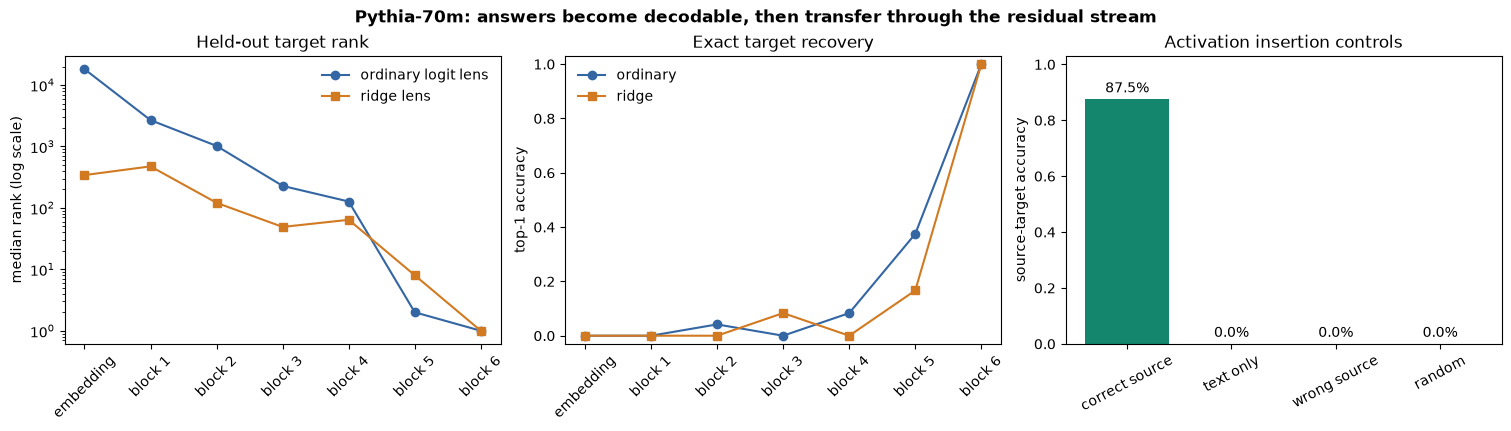

Saved chapter7_activation_to_language/instructions/assets/pythia_lens_patchscope_cpu_signature.png


In [16]:
import pandas as pd

display(pd.DataFrame(lens_result["rows"]))
display(pd.DataFrame(patch_result["rows"]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
stages = list(lens_result["stage_names"])
axes[0].plot(stages, ordinary_median, marker="o", label="ordinary logit lens", color="#3366a3")
axes[0].plot(stages, tuned_median, marker="s", label="ridge lens", color="#d17a22")
axes[0].set_yscale("log")
axes[0].set(title="Held-out target rank", ylabel="median rank (log scale)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(frameon=False)

axes[1].plot(stages, lens_result["logit_accuracy"], marker="o", label="ordinary", color="#3366a3")
axes[1].plot(stages, lens_result["tuned_accuracy"], marker="s", label="ridge", color="#d17a22")
axes[1].set(title="Exact target recovery", ylabel="top-1 accuracy", ylim=(-0.03, 1.03))
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(frameon=False)

control_names = ["correct source", "text only", "wrong source", "random"]
control_values = [patch_result["patched_accuracy"], patch_result["text_only_accuracy"], patch_result["wrong_source_accuracy"], patch_result["random_accuracy"]]
axes[2].bar(control_names, control_values, color=["#14866d", "#777777", "#bd4f5c", "#8c6bb1"])
axes[2].set(title="Activation insertion controls", ylabel="source-target accuracy", ylim=(0, 1.03))
axes[2].tick_params(axis="x", rotation=28)
for index, value in enumerate(control_values):
    axes[2].text(index, value + 0.025, f"{value:.1%}", ha="center")

fig.suptitle("Pythia-70m: answers become decodable, then transfer through the residual stream", fontweight="bold")
asset_path = root_dir / chapter / "instructions" / "assets" / "pythia_lens_patchscope_cpu_signature.png"
fig.savefig(asset_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {asset_path.relative_to(root_dir)}")


## Try It Yourself - move the insertion point

Change `PLAY_BLOCK` from 5 to an earlier layer. Before running, predict whether correct-source accuracy and log-probability gain will fall, and whether the wrong-source control will remain low.


In [17]:
PLAY_BLOCK = 4  # Try 0 through 5.
play_result = evaluate_pythia_patchscope(model, tokenizer, heldout_cache, block_index=PLAY_BLOCK)
print({key: value for key, value in play_result.items() if key.endswith("accuracy") or "logprob_gain" in key})


{'patched_accuracy': 0.4583333432674408, 'text_only_accuracy': 0.0, 'wrong_source_accuracy': 0.0, 'random_accuracy': 0.0, 'patched_mean_logprob_gain': 6.722666263580322, 'wrong_source_mean_logprob_gain': 1.1376899480819702, 'random_mean_logprob_gain': -1.284226655960083}


## Bonus Anomaly Hunt

Find a held-out prompt where the ridge lens worsens target rank. Inspect its ordinary and tuned top tokens across layers. Then change the ridge coefficient and decide whether the failure is under-regularization, over-regularization, or a target whose representation is genuinely non-linear at that stage.

## Limitations

The targets are Pythia's own next-token argmax, not human truth. The 24 held-out prompts cover several meaningful factual and syntactic families but are not a benchmark. Activation insertion uses one neutral target template and one position. Success shows source information survives one remaining block; it does not show the decoded word is a complete natural-language explanation of the activation.


## Optional Release Verification Contract

The learner results above are recomputed from local CPU models and do not depend on this handoff. The committed `verification_report.json` records separate historical release evidence. These entry points are defined for course tooling only; this notebook deliberately does not call the GPU path.

In [18]:
def load_verification_evidence() -> dict:
    import json

    report = json.loads((section_dir / "verification_report.json").read_text())
    required = {"accepted", "metrics", "gt_tier", "notebook_id"}
    missing = sorted(required - report.keys())
    if missing:
        raise ValueError(f"verification report is missing required fields: {missing}")
    return report


def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    from importlib import import_module

    module = import_module(
        f"chapter7_activation_to_language.exercises.{section}.solutions"
    )
    return module.run_gpu_test(max_vram_gb=max_vram_gb)


def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    return run_gpu_test(max_vram_gb=max_vram_gb)


# Deliberately do not call release verification during the CPU learner run.